# 03 — Volatility regime (H3)

> **Data notice.** Values are real daily revenue multiplied by a single constant scaling factor for privacy. All statistical properties (patterns, breaks, tests, coefficients) are identical to those on the raw data — only the absolute currency level is hidden. Units labeled **LC** (local currency, scaled).

**Hypothesis (as stated):** variance of daily revenue in the post-March-2020 regime is significantly higher than the pre-COVID baseline. Pass criterion: variance ratio ≥ 1.5× AND test p < 0.01.

**EDA hint:** post-COVID regime stds are all *lower* than pre-COVID → H3 as stated likely FALSE, and the DISCOVERY direction would be that variance *decreased*.

**Approach:** rolling 30-day std chart (visual) → pooled Levene's + F-test → bridge to regime-level analysis → within-regime Levene's tests with Bonferroni correction → synthesis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.dates as mdates
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams['figure.dpi'] = 110

In [2]:
df = pd.read_csv('../data/daily_sales_final.csv', parse_dates=['date'])
df = df.set_index('date').sort_index()
y = df['revenue_scaled']
print(f'Coverage: {y.index.min().date()} to {y.index.max().date()}')
print(f'Non-missing days: {y.notna().sum()}')

Coverage: 2019-12-15 to 2021-05-10
Non-missing days: 470


## Regime segmentation

In [3]:
regimes = {
    'Pre-COVID':         ('2019-12-15', '2020-03-25'),
    'Acute crash':       ('2020-03-26', '2020-05-26'),
    'Partial rebound':   ('2020-05-27', '2020-12-01'),
    'Terminal decline': ('2020-12-02', '2021-05-10'),
}

regime_series = {name: y.loc[start:end].dropna() for name, (start, end) in regimes.items()}

for name, s in regime_series.items():
    print(f'{name:20s} n={len(s):4d}  mean={s.mean():>8,.0f}  std={s.std():>7,.0f}')

Pre-COVID            n=  95  mean= 143,653  std= 23,645
Acute crash          n=  55  mean=  86,760  std= 15,256
Partial rebound      n= 175  mean= 125,415  std= 21,021
Terminal decline     n= 145  mean= 110,575  std= 17,649


## Rolling 30-day std chart

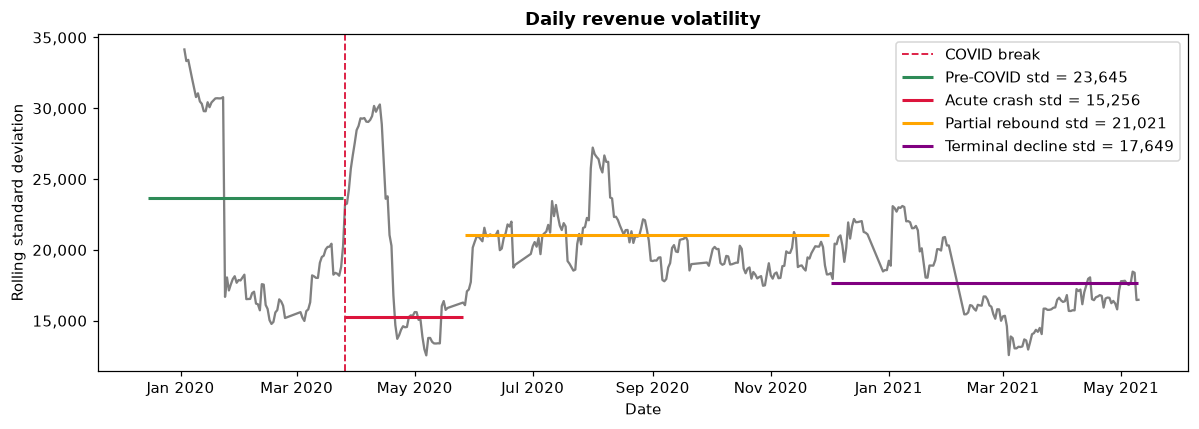

In [4]:
rolling_std = y.rolling(30, min_periods=20).std()
fig, ax = plt.subplots()
ax.plot(rolling_std.index, rolling_std.values, color="grey")
ax.set(xlabel="Date", ylabel="Rolling standard deviation", title="Daily revenue volatility")
ax.axvline(pd.Timestamp("2020-03-26"), color="crimson", linestyle="--", linewidth=1.2, label="COVID break")
colors = ["seagreen", "crimson", "orange", "purple"]
for (name, (start, end)), c in zip(regimes.items(), colors):
    seg_std = regime_series[name].std()
    ax.hlines(seg_std, xmin=pd.Timestamp(start), xmax=pd.Timestamp(end), colors=c,
              linewidth=2, label=f"{name} std = {seg_std:,.0f}")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../charts/h3_rolling_std.png", dpi=120, bbox_inches="tight")
plt.show()

## Pooled variance ratio

In [5]:
pre_covid = y[:"2020-03-25"]
post_covid = y["2020-03-26":]
print(f"{'':<11}  {'n':>4}  {'mean':>10}  {'std':>8}  {'var':>14}")
print(f"{'pre-COVID':<11}  {len(pre_covid):>4d}  {pre_covid.mean():>10,.0f}  {pre_covid.std():>8,.0f}  {pre_covid.var():>14,.0f}")
print(f"{'post-COVID':<11}  {len(post_covid):>4d}  {post_covid.mean():>10,.0f}  {post_covid.std():>8,.0f}  {post_covid.var():>14,.0f}")
var_ratio = post_covid.var() / pre_covid.var()
print(f"\nvariance ratio (post/pre) = {var_ratio:.3f}")

                n        mean       std             var
pre-COVID      95     143,653    23,645     559,106,846
post-COVID    375     114,008    23,103     533,746,999

variance ratio (post/pre) = 0.955


## Levene's on pooled

In [6]:
statistic, p_value = stats.levene(pre_covid, post_covid, center='median')
print(f"statistic: {statistic:.3f}")
print(f"p-value  : {p_value:.4f}")

statistic: 2.255
p-value  : 0.1338


## F-test on pooled

In [7]:
f_stat = pre_covid.var() / post_covid.var()
df1, df2 = len(pre_covid) - 1, len(post_covid) - 1
p_value = 2 * min(stats.f.cdf(f_stat, df1, df2), 
                  1 - stats.f.cdf(f_stat, df1, df2))
print(f"{'F-statistic':<15}: {f_stat:.4f}")
print(f"{'df (num, denom)':<15}: ({df1}, {df2})")
print(f"{'p-value':<15}: {p_value:.4f}")

F-statistic    : 1.0475
df (num, denom): (94, 374)
p-value        : 0.7505


The pooled tests find no variance change (ratio 0.955, Levene's p ≈ 0.134, F-test p ≈ 0.750). Taken alone, they would settle the question — H3 not rejected. But the rolling-std chart tells a different story: three post-COVID regimes with visibly distinct volatility levels (~15k / ~21k / ~18k), all below pre-COVID's ~24k. That visible heterogeneity is what motivates the discovery phase — a regime-by-regime comparison to see whether the pooled test is missing structure that the chart makes obvious.

## Within-regime comparison

In [8]:
from IPython.display import display

post_regime_names = ['Acute crash', 'Partial rebound', 'Terminal decline']
alpha_bonf = 0.05 / 3

rows = []
for name in post_regime_names:
    regime_data = regime_series[name].dropna()
    var_regime = regime_data.var()
    ratio = var_regime / pre_covid.var()
    stat, p = stats.levene(pre_covid, regime_data, center='median')
    rows.append({
        'Regime': name,
        'n': len(regime_data),
        'Variance': f'{var_regime/1e6:.1f}M',
        'Ratio vs pre': f'{ratio:.3f}',
        "Levene's p": f'{p:.4f}',
        'Significant (α=0.017)': 'yes' if p < alpha_bonf else 'no',
    })

regime_df = pd.DataFrame(rows).set_index('Regime')
display(regime_df)

,n,Variance,Ratio vs pre,Levene's p,Significant (α=0.017)
Regime,,,,,
Acute crash,55,232.8M,0.416,0.0743,no
Partial rebound,175,441.9M,0.790,0.6579,no
Terminal decline,145,311.5M,0.557,0.1346,no


## Verdict

Recall the pooled tests failed to reject equal variances (Levene's p = 0.134, F-test p = 0.750, variance ratio 0.955). A naive pooled reading concludes no evidence of any variance change — but this misses the pattern the data actually contain, as the discovery phase revealed.

The pooled test's blindness has a clean explanation. Total variance of a series with regime-level mean shifts decomposes as within-regime variance + variance of regime means. The three post-COVID regimes have very different means (~87k / 125k / 111k), so the between-regime term inflates the pooled variance and hides the within-regime volatility drop. The methodological point: variance tests on pooled non-stationary series are unreliable — the correct level of analysis is regime-by-regime.

H3 as originally stated ("post-COVID variance HIGHER") is FALSE. All three post-COVID regime variances are strictly below the pre-COVID baseline (ratios 0.42, 0.79, 0.56).

The DISCOVERY direction — that post-COVID volatility is LOWER — is supported by the size of every within-regime variance ratio but is not formally confirmed under conservative testing. Levene's test at Bonferroni-corrected α = 0.017 fails to reject equal variances for any of the three regimes (best case: acute crash, p = 0.074). This reflects Levene's deliberate robustness against non-normal data combined with modest per-regime sample sizes. The directional pattern is consistent; formal significance is not achievable with the current sample.

On the business side, the plausible mechanism is a compositional shift in the revenue mix. Pandemic-era lockdowns and reduced discretionary spending compressed the volatile over-the-counter component of daily sales, leaving stable chronic-prescription demand as a larger share of the total. A revenue mix dominated by predictable refill cycles is inherently smoother day-to-day than one mixed with discretionary purchases — the observed within-regime volatility drop is a natural consequence.
